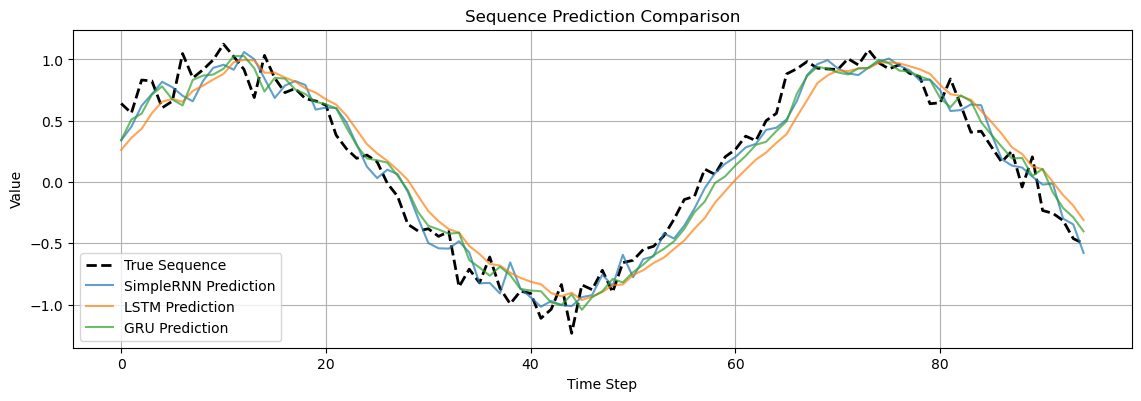

In [1]:
import tkinter as tk
from tkinter import ttk
import numpy as np
import threading
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Input
from tensorflow.keras.callbacks import Callback

class GUICallback(Callback):
    def __init__(self, console_widget, model_name):
        super().__init__()
        self.console = console_widget
        self.model_name = model_name

    def on_epoch_end(self, epoch, logs=None):
        loss = logs.get('loss')
        msg = f"[{self.model_name}] Epoch {epoch+1} - Loss: {loss:.4f}\n"
        self.console.insert(tk.END, msg)
        self.console.see(tk.END)

class SequencePredictorApp:
    def __init__(self, root):
        self.root = root
        self.root.title("RNN Sequence Predictor (SimpleRNN, LSTM, GRU)")
        self.root.geometry("1200x800")
        
        self.models_data = {}
        self.scaler = MinMaxScaler(feature_range=(0, 1))
        self.sequence_data = []
        
        self.create_widgets()

    def create_widgets(self):
        # --- Top Frame: Controls ---
        top_frame = ttk.Frame(self.root, padding=10)
        top_frame.pack(side=tk.TOP, fill=tk.X)

        # Sequence Selection (Top Left)
        ttk.Label(top_frame, text="Sequence:").grid(row=0, column=0, padx=5)
        self.seq_var = tk.StringVar(value="Real sequence (Sine)")
        seq_cb = ttk.Combobox(top_frame, textvariable=self.seq_var, state="readonly", width=20)
        seq_cb['values'] = ["Real sequence (Sine)", "Arithmetic sequence", 
                            "Geometric sequence", "Fibonacci sequence", 
                            "Cauchy Sequence", "Triangular Number Sequence"]
        seq_cb.grid(row=0, column=1, padx=5)

        # Middle Controls
        ttk.Label(top_frame, text="Timesteps:").grid(row=0, column=2, padx=5)
        self.timesteps_var = tk.IntVar(value=5)
        ttk.Entry(top_frame, textvariable=self.timesteps_var, width=5).grid(row=0, column=3, padx=5)

        ttk.Label(top_frame, text="Epochs:").grid(row=0, column=4, padx=5)
        self.epochs_var = tk.IntVar(value=50)
        ttk.Entry(top_frame, textvariable=self.epochs_var, width=5).grid(row=0, column=5, padx=5)

        ttk.Label(top_frame, text="Optimizer:").grid(row=0, column=6, padx=5)
        self.opt_var = tk.StringVar(value="adam")
        opt_cb = ttk.Combobox(top_frame, textvariable=self.opt_var, state="readonly", width=8)
        opt_cb['values'] = ["adam", "sgd", "rmsprop"]
        opt_cb.grid(row=0, column=7, padx=5)

        ttk.Label(top_frame, text="Batch Size:").grid(row=0, column=8, padx=5)
        self.batch_var = tk.IntVar(value=8)
        ttk.Entry(top_frame, textvariable=self.batch_var, width=5).grid(row=0, column=9, padx=5)

        # Run Button (Top Right)
        self.run_btn = ttk.Button(top_frame, text="Run Models", command=self.start_training)
        self.run_btn.grid(row=0, column=10, padx=20)

        # --- Center Frame: Plot ---
        plot_frame = ttk.Frame(self.root)
        plot_frame.pack(side=tk.TOP, fill=tk.BOTH, expand=True)
        
        self.fig, self.ax = plt.subplots(figsize=(10, 4))
        self.canvas = FigureCanvasTkAgg(self.fig, master=plot_frame)
        self.canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

        # --- Checkboxes for Plot ---
        check_frame = ttk.Frame(self.root)
        check_frame.pack(side=tk.TOP, fill=tk.X, pady=5)
        
        self.show_rnn = tk.BooleanVar(value=True)
        self.show_lstm = tk.BooleanVar(value=True)
        self.show_gru = tk.BooleanVar(value=True)
        
        ttk.Checkbutton(check_frame, text="SimpleRNN", variable=self.show_rnn, command=self.update_plot).pack(side=tk.LEFT, padx=20)
        ttk.Checkbutton(check_frame, text="LSTM", variable=self.show_lstm, command=self.update_plot).pack(side=tk.LEFT, padx=20)
        ttk.Checkbutton(check_frame, text="GRU", variable=self.show_gru, command=self.update_plot).pack(side=tk.LEFT, padx=20)

        # --- Bottom Frame: Text Areas ---
        bottom_frame = ttk.Frame(self.root)
        bottom_frame.pack(side=tk.BOTTOM, fill=tk.BOTH, expand=True, padx=10, pady=10)
        
        bottom_frame.columnconfigure((0,1,2,3), weight=1)

        self.console_text = self.create_text_area(bottom_frame, "Console (Epochs)", 0)
        self.loss_text = self.create_text_area(bottom_frame, "Final Loss", 1)
        self.true_text = self.create_text_area(bottom_frame, "True Sequence", 2)
        self.pred_text = self.create_text_area(bottom_frame, "Predicted Values", 3)

    def create_text_area(self, parent, title, col):
        frame = ttk.LabelFrame(parent, text=title)
        frame.grid(row=0, column=col, sticky="nsew", padx=5)
        text_widget = tk.Text(frame, height=10, width=25)
        text_widget.pack(fill=tk.BOTH, expand=True)
        return text_widget

    def generate_sequence(self):
        n = 100 # Length of sequence
        seq_type = self.seq_var.get()
        x_idx = np.arange(1, n + 1)
        
        if seq_type == "Real sequence (Sine)":
            seq = np.sin(x_idx * 0.1) + np.random.normal(0, 0.1, n)
        elif seq_type == "Arithmetic sequence":
            seq = 2 + 3 * x_idx
        elif seq_type == "Geometric sequence":
            seq = 2 * (1.05 ** x_idx) # small ratio to prevent overflow
        elif seq_type == "Fibonacci sequence":
            seq = np.zeros(n)
            seq[0], seq[1] = 1, 1
            for i in range(2, n):
                seq[i] = seq[i-1] + seq[i-2]
        elif seq_type == "Cauchy Sequence":
            seq = 1.0 / x_idx
        elif seq_type == "Triangular Number Sequence":
            seq = (x_idx * (x_idx + 1)) / 2
            
        self.sequence_data = seq.reshape(-1, 1)

    def prepare_data(self):
        scaled_data = self.scaler.fit_transform(self.sequence_data)
        X, y = [], []
        timesteps = self.timesteps_var.get()
        for i in range(len(scaled_data) - timesteps):
            X.append(scaled_data[i:(i + timesteps), 0])
            y.append(scaled_data[i + timesteps, 0])
        return np.array(X)[..., np.newaxis], np.array(y)

    def build_model(self, model_type):
        model = Sequential()
        timesteps = self.timesteps_var.get()
        
        model.add(Input(shape=(timesteps, 1)))
        
        if model_type == 'RNN':
            model.add(SimpleRNN(50, activation='relu'))
        elif model_type == 'LSTM':
            model.add(LSTM(50, activation='relu'))
        elif model_type == 'GRU':
            model.add(GRU(50, activation='relu'))
            
        model.add(Dense(1))
        model.compile(optimizer=self.opt_var.get(), loss='mse')
        return model

    def start_training(self):
        self.run_btn.config(state=tk.DISABLED)
        self.console_text.delete(1.0, tk.END)
        self.loss_text.delete(1.0, tk.END)
        self.true_text.delete(1.0, tk.END)
        self.pred_text.delete(1.0, tk.END)
        
        # Run in thread to keep GUI responsive
        threading.Thread(target=self.run_models, daemon=True).start()

    def run_models(self):
        self.generate_sequence()
        X, y = self.prepare_data()
        epochs = self.epochs_var.get()
        batch_size = self.batch_var.get()

        # Print true values
        self.true_text.insert(tk.END, np.array2string(self.sequence_data.flatten()[:50], precision=2))

        models_to_train = [('RNN', SimpleRNN), ('LSTM', LSTM), ('GRU', GRU)]
        self.models_data = {}

        for name, _ in models_to_train:
            self.console_text.insert(tk.END, f"\n--- Training {name} ---\n")
            model = self.build_model(name)
            
            gui_callback = GUICallback(self.console_text, name)
            history = model.fit(X, y, epochs=epochs, batch_size=batch_size, verbose=0, callbacks=[gui_callback])
            
            predictions = model.predict(X, verbose=0)
            predictions_inv = self.scaler.inverse_transform(predictions)
            
            final_loss = history.history['loss'][-1]
            self.loss_text.insert(tk.END, f"{name}: {final_loss:.6f}\n")
            
            self.pred_text.insert(tk.END, f"--- {name} Preds ---\n")
            self.pred_text.insert(tk.END, np.array2string(predictions_inv.flatten()[:20], precision=2))
            self.pred_text.insert(tk.END, "\n")
            self.models_data[name] = predictions_inv.flatten()

        # Update GUI after thread finishes
        self.root.after(0, self.training_finished)

    def training_finished(self):
        self.update_plot()
        self.run_btn.config(state=tk.NORMAL)

    def update_plot(self):
        self.ax.clear()
        if len(self.sequence_data) == 0:
            return

        timesteps = self.timesteps_var.get()
        actual_plot_data = self.sequence_data[timesteps:].flatten()
        
        self.ax.plot(actual_plot_data, label='True Sequence', color='black', linewidth=2, linestyle='--')

        if 'RNN' in self.models_data and self.show_rnn.get():
            self.ax.plot(self.models_data['RNN'], label='SimpleRNN Prediction', alpha=0.7)
        if 'LSTM' in self.models_data and self.show_lstm.get():
            self.ax.plot(self.models_data['LSTM'], label='LSTM Prediction', alpha=0.7)
        if 'GRU' in self.models_data and self.show_gru.get():
            self.ax.plot(self.models_data['GRU'], label='GRU Prediction', alpha=0.7)

        self.ax.set_title("Sequence Prediction Comparison")
        self.ax.set_xlabel("Time Step")
        self.ax.set_ylabel("Value")
        self.ax.legend()
        self.ax.grid(True)
        self.canvas.draw()

if __name__ == "__main__":
    root = tk.Tk()
    app = SequencePredictorApp(root)
    root.mainloop()
